In [25]:
import sys
import os

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_fastf1 import load_season_results, load_multiple_seasons
from src.features.build_features import build_driver_features, add_rolling_features

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [26]:
# Load multiple seasons (2023 and 2024)
from src.data.load_fastf1 import load_multiple_seasons

years_to_load = [2023, 2024]

print(f"Loading {len(years_to_load)} seasons: {years_to_load}\n")

all_seasons_df = load_multiple_seasons(years_to_load, cache_dir="../cache")

print(f"\n✓ Loaded {len(all_seasons_df)} total race results")
print(f"  Years: {sorted(all_seasons_df['Year'].unique())}")
print(f"  Total races:  {all_seasons_df['Race'].nunique()}")
print(f"  Total drivers: {all_seasons_df['DriverFull'].nunique()}")

# Show distribution by year
print(f"\nRaces per year:")
for year in years_to_load:
    year_data = all_seasons_df[all_seasons_df['Year'] == year]
    print(f"  {year}: {year_data['Race'].nunique()} races, {year_data['DriverFull'].nunique()} drivers")

all_seasons_df.head(10)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2 seasons: [2023, 2024]


Loading 2023 Season
Loading Round 1:  Bahrain Grand Prix...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Round 2:  Saudi Arabian Grand Prix...


...

core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req         

Loading Round 24:  Abu Dhabi Grand Prix...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']



✓ Loaded 479 race results from 2024 season
  Drivers: 24
  Races: 24

✓ Total:  919 race results across 2 seasons

✓ Loaded 919 total race results
  Years: [np.int64(2023), np.int64(2024)]
  Total races:  24
  Total drivers: 25

Races per year:
  2023: 22 races, 22 drivers
  2024: 24 races, 24 drivers


,Year,Round,Race,Date,DriverFull,Driver,Team,Position,GridPosition,Points,Status,Time
0,2023,1,Bahrain Grand Prix,2023-03-05,Max Verstappen,VER,Red Bull Racing,1.0,1.0,25.0,Finished,0 days 01:33:56.736000
1,2023,1,Bahrain Grand Prix,2023-03-05,Sergio Perez,PER,Red Bull Racing,2.0,2.0,18.0,Finished,0 days 00:00:11.987000
2,2023,1,Bahrain Grand Prix,2023-03-05,Fernando Alonso,ALO,Aston Martin,3.0,5.0,15.0,Finished,0 days 00:00:38.637000
3,2023,1,Bahrain Grand Prix,2023-03-05,Carlos Sainz,SAI,Ferrari,4.0,4.0,12.0,Finished,0 days 00:00:48.052000
4,2023,1,Bahrain Grand Prix,2023-03-05,Lewis Hamilton,HAM,Mercedes,5.0,7.0,10.0,Finished,0 days 00:00:50.977000
5,2023,1,Bahrain Grand Prix,2023-03-05,Lance Stroll,STR,Aston Martin,6.0,8.0,8.0,Finished,0 days 00:00:54.502000
6,2023,1,Bahrain Grand Prix,2023-03-05,George Russell,RUS,Mercedes,7.0,6.0,6.0,Finished,0 days 00:00:55.873000
7,2023,1,Bahrain Grand Prix,2023-03-05,Valtteri Bottas,BOT,Alfa Romeo,8.0,12.0,4.0,Finished,0 days 00:01:12.647000
8,2023,1,Bahrain Grand Prix,2023-03-05,Pierre Gasly,GAS,Alpine,9.0,20.0,2.0,Finished,0 days 00:01:13.753000
9,2023,1,Bahrain Grand Prix,2023-03-05,Alexander Albon,ALB,Williams,10.0,15.0,1.0,Finished,0 days 00:01:29.774000


In [27]:
# Build features for each season
all_features = []

for year in years_to_load: 
    print(f"\nBuilding features for {year}...")
    season_data = all_seasons_df[all_seasons_df['Year'] == year]
    
    features = build_driver_features(season_data)
    all_features.append(features)
    
    print(f"  ✓ Created features for {len(features)} drivers")

# Combine all seasons
features_df = pd.concat(all_features, ignore_index=True)

print(f"\n✓ Total driver-season records: {len(features_df)}")
features_df.head(10)


Building features for 2023...
  ✓ Created features for 22 drivers

Building features for 2024...
  ✓ Created features for 24 drivers

✓ Total driver-season records: 46


,Year,Driver,Team,TotalRaces,TotalPoints,AvgPoints,StdPoints,AvgFinish,MedianFinish,AvgGrid,Podiums,Wins,PodiumRate,WinRate,DNFs,DNFRate,AvgPositionChange
0,2023,Max Verstappen,Red Bull Racing,22,530.0,24.090909,3.778499,1.272727,1.0,3.181818,21,19,0.954545,0.863636,0,0.000000,1.909091
1,2023,Sergio Perez,Red Bull Racing,22,260.0,11.818182,7.404222,5.863636,4.0,9.272727,9,2,0.409091,0.090909,0,0.000000,3.409091
2,2023,Lewis Hamilton,Mercedes,22,217.0,9.863636,5.709603,6.181818,5.0,6.090909,6,0,0.272727,0.000000,0,0.000000,-0.090909
3,2023,Fernando Alonso,Aston Martin,22,198.0,9.000000,6.531973,6.636364,5.5,6.909091,8,0,0.363636,0.000000,0,0.000000,0.272727
4,2023,Charles Leclerc,Ferrari,22,185.0,8.409091,6.702232,8.227273,5.5,4.954545,6,0,0.272727,0.000000,0,0.000000,-3.272727
5,2023,Lando Norris,McLaren,22,184.0,8.363636,7.467679,8.000000,6.5,7.954545,7,0,0.318182,0.000000,0,0.000000,-0.045455
6,2023,Carlos Sainz,Ferrari,22,178.0,8.090909,6.078135,7.500000,6.0,5.772727,3,1,0.136364,0.045455,0,0.000000,-1.727273
7,2023,George Russell,Mercedes,22,157.0,7.136364,4.892126,8.090909,6.0,6.454545,2,0,0.090909,0.000000,0,0.000000,-1.636364
8,2023,Oscar Piastri,McLaren,22,82.0,3.727273,5.470108,10.909091,10.5,9.636364,2,0,0.090909,0.000000,0,0.000000,-1.272727
9,2023,Lance Stroll,Aston Martin,22,68.0,3.090909,4.069738,10.761905,10.0,11.523810,0,0,0.000000,0.000000,1,0.045455,0.761905


# Select numeric columns for visualization
numeric_cols = ['TotalPoints', 'AvgPoints', 'PodiumRate', 'WinRate', 'DNFRate', 'AvgFinish']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(features_df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

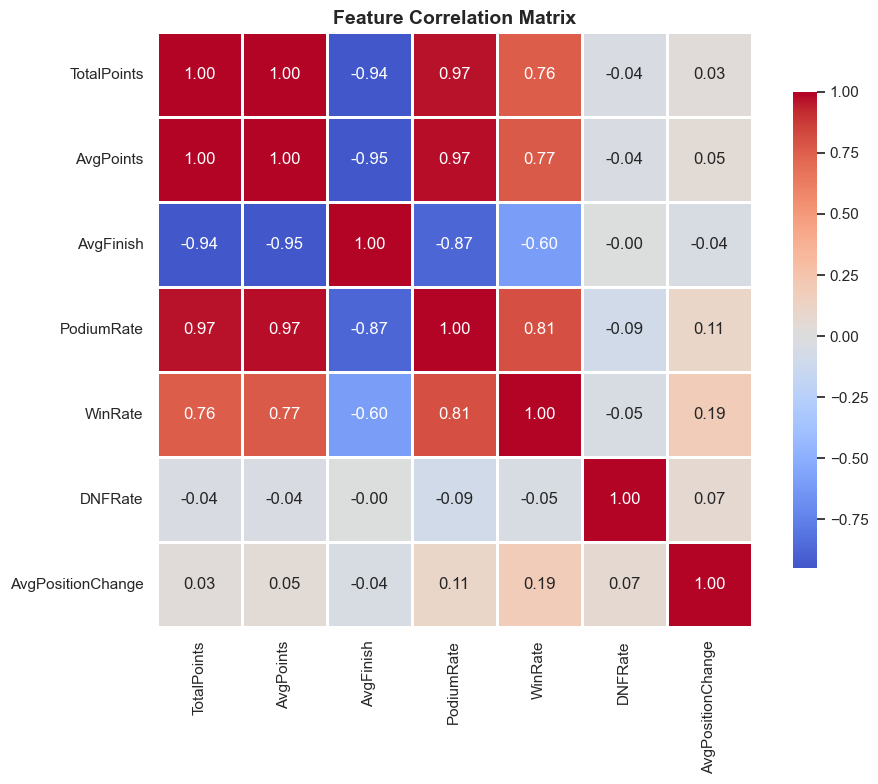


Correlation with TotalPoints:
TotalPoints          1.000000
AvgPoints            0.996940
PodiumRate           0.967102
WinRate              0.756913
AvgPositionChange    0.027047
DNFRate             -0.039594
AvgFinish           -0.940816
Name: TotalPoints, dtype: float64


In [28]:
# Correlation with target variable
correlation_cols = ['TotalPoints', 'AvgPoints', 'AvgFinish', 'PodiumRate', 
                    'WinRate', 'DNFRate', 'AvgPositionChange']

corr_matrix = features_df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with TotalPoints
print("\nCorrelation with TotalPoints:")
print(corr_matrix['TotalPoints'].sort_values(ascending=False))

In [29]:
# Add rolling features (3-season window)
features_df = add_rolling_features(features_df, window=3)

print("✓ Added rolling features")
print("\nNew columns:")
print(features_df[['Driver', 'Year', 'TotalPoints', 'RollingAvgPoints', 
                   'PrevYearPoints', 'PrevYearPodiums']].head(10))

✓ Added rolling features

New columns:
              Driver  Year  TotalPoints  RollingAvgPoints  PrevYearPoints  \
12   Alexander Albon  2023         25.0              25.0             0.0   
37   Alexander Albon  2024         12.0              18.5            25.0   
6       Carlos Sainz  2023        178.0             178.0             0.0   
26      Carlos Sainz  2024        262.0             220.0           178.0   
4    Charles Leclerc  2023        185.0             185.0             0.0   
24   Charles Leclerc  2024        327.0             256.0           185.0   
16  Daniel Ricciardo  2023          6.0               6.0             0.0   
39  Daniel Ricciardo  2024          7.0               6.5             6.0   
10      Esteban Ocon  2023         56.0              56.0             0.0   
35      Esteban Ocon  2024         23.0              39.5            56.0   

    PrevYearPodiums  
12              0.0  
37              0.0  
6               0.0  
26              3.0  
4  

Top 10 Drivers in 2024:
             Driver             Team  TotalPoints  Wins  Podiums  DNFs
22   Max Verstappen  Red Bull Racing        399.0     9       14     0
23     Lando Norris          McLaren        344.0     4       13     0
24  Charles Leclerc          Ferrari        327.0     3       13     0
25    Oscar Piastri          McLaren        265.0     2        8     0
26     Carlos Sainz          Ferrari        262.0     2        9     0
27   George Russell         Mercedes        226.0     2        4     0
28   Lewis Hamilton         Mercedes        207.0     2        5     0
29     Sergio Perez  Red Bull Racing        138.0     0        4     0
30  Fernando Alonso     Aston Martin         70.0     0        0     0
31     Pierre Gasly           Alpine         40.0     0        1     0


C:\Users\Paul\AppData\Local\Temp\ipykernel_4796\4134204859.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_drivers, x='Driver', y='TotalPoints', palette='viridis')


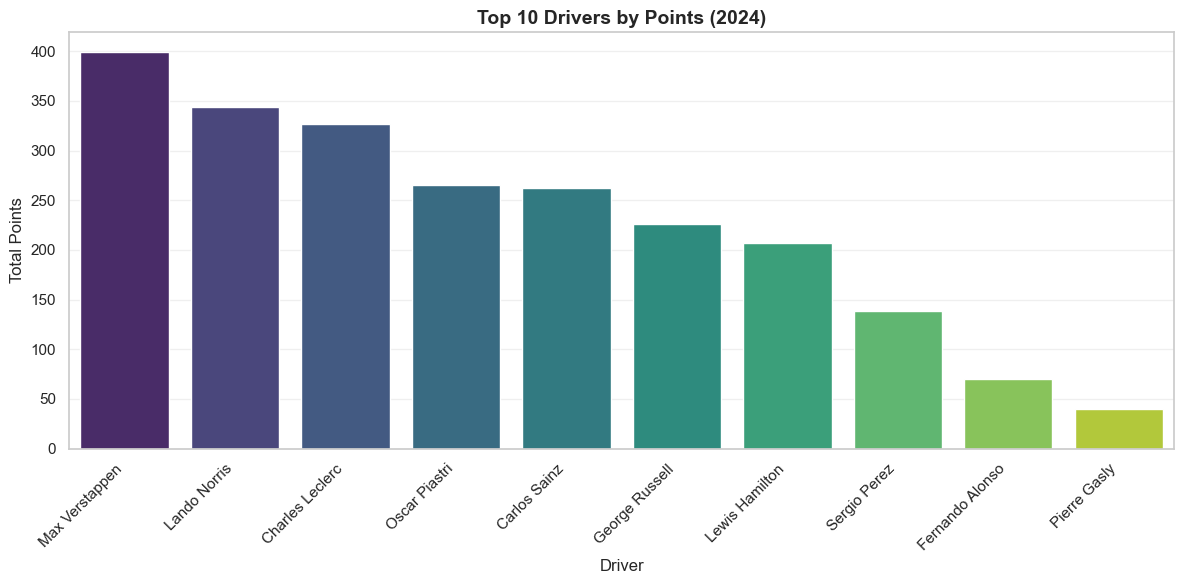

In [30]:
# Top 10 drivers by total points in most recent season
latest_year = features_df['Year'].max()
top_drivers = features_df[features_df['Year'] == latest_year]. nlargest(10, 'TotalPoints')

print(f"Top 10 Drivers in {latest_year}:")
print(top_drivers[['Driver', 'Team', 'TotalPoints', 'Wins', 'Podiums', 'DNFs']])

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=top_drivers, x='Driver', y='TotalPoints', palette='viridis')
plt.title(f'Top 10 Drivers by Points ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Driver')
plt.ylabel('Total Points')
plt. xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
print("Missing values in features:")
print(features_df. isna().sum())

# Fill any remaining NaN with 0 (for drivers in their first season)
features_df = features_df.fillna(0)

Missing values in features:
Year                 0
Driver               0
Team                 0
TotalRaces           0
TotalPoints          0
AvgPoints            0
StdPoints            1
AvgFinish            0
MedianFinish         0
AvgGrid              0
Podiums              0
Wins                 0
PodiumRate           0
WinRate              0
DNFs                 0
DNFRate              0
AvgPositionChange    0
RollingAvgPoints     0
RollingPodiumRate    0
PrevYearPoints       0
PrevYearPodiums      0
dtype: int64


In [32]:
# Save to processed data folder
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "driver_features.csv")
features_df.to_csv(output_path, index=False)

print(f"✓ Features saved to {output_path}")
print(f"  Shape: {features_df.shape}")
print(f"  Years: {sorted(features_df['Year'].unique())}")
print(f"  Drivers: {features_df['Driver'].nunique()}")

✓ Features saved to ../data/processed\driver_features.csv
  Shape: (46, 21)
  Years: [np.int64(2023), np.int64(2024)]
  Drivers: 25
